In [1]:
from sklearn.model_selection import TimeSeriesSplit
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from scipy.stats import jarque_bera
from statsmodels.stats.stattools import durbin_watson
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score

In [2]:
# ALC
# create a time series split. the default number of splits 
# is 5. We'll keep this for now and optimize later
# following scikit-learn guidance
# we use this for cross-validation sets to try to control overfitting
tscv = TimeSeriesSplit()

In [3]:
# ALC
# read in datasets
# using "X" and "y" because scikit-learn's
# guidances uses X and y.
X = pd.read_csv("../data/training_data_v2.csv")
X_test = pd.read_csv("../data/test_data_v2.csv")

X["service_date"] = pd.to_datetime(X["service_date"])

# time series split will require this
X = X.sort_values('service_date').reset_index(drop=True)

# set our outcome as y
y = X['est_ridership']
y_test = X_test['est_ridership']

# drop outcome and string date
X = X.drop(['est_ridership', 'service_date'], axis = 1)
X_test = X_test.drop(['est_ridership', 'service_date'], axis = 1)

In [4]:
# ALC
# drop columns we already did PCA with and their transformations
features_to_drop = ['num_alerts', 'num_alerts_log', 
            'alert_effect_shuttle', 'alert_effect_delay',
           'alert_effect_shuttle_log', 'alert_effect_delay_log',
           'num_slow_zones', 'num_slow_zones_sqrt',
           'total_track_pct', 'total_track_pct_log',
           'total_miles_affected']
X = X.drop(features_to_drop, axis = 1)
X_test = X_test.drop(features_to_drop, axis = 1)

In [5]:
# ALC
# create RandomForestRegressor
rfr = RandomForestRegressor(random_state=42)

In [6]:
# ALC
# we can tune some parameters here, more on that later
param_grid = { 
    'n_estimators': [100, 500],
    'max_features': ['sqrt', 'log2'],
    'max_depth': [4,5,6,7,8]
}

In [7]:
# ALC
# find the best combo of the above parameters
CV_rfr = GridSearchCV(estimator = rfr, param_grid = param_grid, cv = tscv)
CV_rfr.fit(X, y)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 500]})

In [8]:
# ALC
# see the best params
CV_rfr.best_params_

{'max_depth': 7, 'max_features': 'sqrt', 'n_estimators': 100}

In [9]:
# ALC
# see the best R^2
CV_rfr.best_score_

0.7835974052652113

In [10]:
# ALC
# fit
CV_rfr.fit(X, y)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=RandomForestRegressor(random_state=42),
             param_grid={'max_depth': [4, 5, 6, 7, 8],
                         'max_features': ['sqrt', 'log2'],
                         'n_estimators': [100, 500]})

In [11]:
# ALC
# predict
y_pred = CV_rfr.predict(X_test)

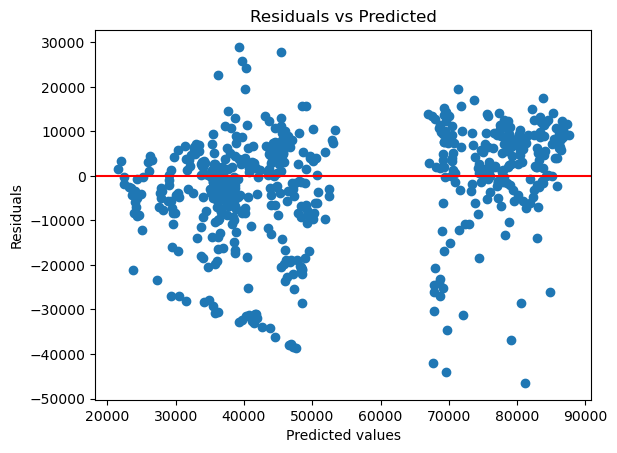

In [12]:
# ALC
# plot residuals
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y = 0, color = 'red')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted')
plt.show()

In [13]:
# predictions for y
y_pred = CV_rfr.predict(X_test)

# gauges for how well we did
mse  = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"R2: {r2}")

MSE: 146204826.03585243
RMSE: 12091.518764648734
R2: 0.7730902612990801


In [14]:
# ALC
# this is not super relevant to RF but we may use it to
# gauge what future models we should use
resid = y_test - y_pred
jb_stat, jb_p = jarque_bera(resid)
print({"JB": jb_stat, "p_value": jb_p})

{'JB': 148.54900697991505, 'p_value': 5.5334117531278844e-33}


In [15]:
# ALC
# from scikit-learn doc
best_rf = CV_rfr.best_estimator_ 
importances = best_rf.feature_importances_
std = np.std([tree.feature_importances_ for tree in best_rf.estimators_], axis = 0)

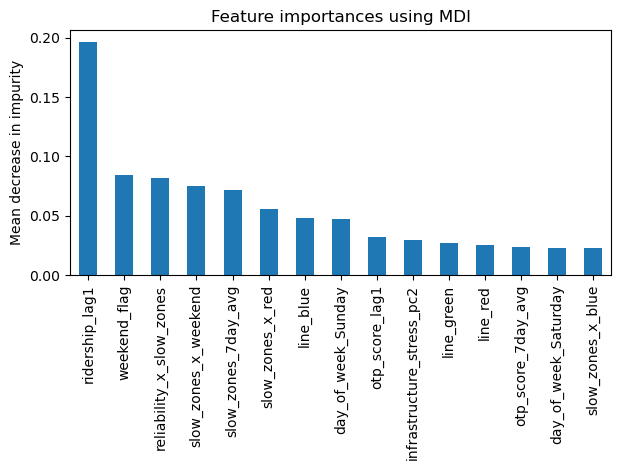

In [16]:
# ALC
# from scikit-learn doc
forest_importances = pd.Series(importances, index=X.columns)
forest_importances = forest_importances.sort_values(ascending = False).nlargest(15)
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()

In [17]:
# ALC 
# from scikit-learn doc
from sklearn.inspection import permutation_importance
result = permutation_importance(
    best_rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=2
)

forest_importances = pd.Series(result.importances_mean, index=X.columns)
forest_importances = forest_importances.sort_values(ascending = False).nlargest(15)

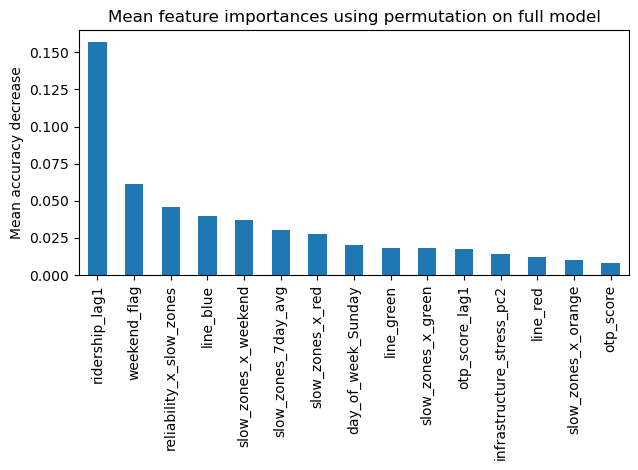

In [18]:
# ALC
# from scikit-learn doc
fig, ax = plt.subplots()
forest_importances.plot.bar(ax=ax)
ax.set_title("Mean feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [19]:
# ALC
# get a glimpse of most important features
# sort descending
forest_importances = forest_importances.sort_values(ascending = False)
# see top 20. 20 is a lot though.
top_n = 20
top_features = forest_importances.head(top_n)
print(top_features)

ridership_lag1               0.157004
weekend_flag                 0.061070
reliability_x_slow_zones     0.045717
line_blue                    0.040075
slow_zones_x_weekend         0.037369
slow_zones_7day_avg          0.030257
slow_zones_x_red             0.027423
day_of_week_Sunday           0.020082
line_green                   0.018437
slow_zones_x_green           0.018419
otp_score_lag1               0.017705
infrastructure_stress_pc2    0.014194
line_red                     0.012440
slow_zones_x_orange          0.010235
otp_score                    0.008395
dtype: float64
